In [ ]:
import geopops
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import starsim as ss
import json
import os
import warnings
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module=r"starsim\.utils",
)
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        category=RuntimeWarning,
        module=r"starsim\.arrays",
    )
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*verify_integrity.*")

# Test race/ethnicity
Previous versions of GeoPops had a race_ethnicity variable in people_all.csv (and the Starsim People object created from people_all.csv). This variable was created from the variables race_black_alone, race_hispanic, and race_white_alone, which are exported in people.csv and come from PUMS sample households. But race_black_alone and race_hispanic were not mutually exclusive, which created issues with the race_ethnicity variable. Now, the race_ethnicity has been removed from people_all.csv. To avoid confusion, we use all the race categories available in PUMS sample households, which are not mutually exclusive:

* race_white_alone
* race_black_alone
* race_amerindian_or_alaskan
* race_asian_alone
* race_pacific_alone
* race_other_alone
* race_two_or_more
* hispanic

These variables are present in PUMS sample household variables and were added to the `additional_traits` dictionary in the config.json file to include them in the GeoPops population. 

Caveat: While these variables are present in the PUMS data, they are not currently used in the combinatorial optimization (CO) step with ACS data. So the distributions of these race/ethnicity categories in a GeoPops population may not be representative of the same population in the ACS data. Right now, GeoPops only matches on race of householder (race_black_alone, hispanic, or white_non_hispanic) from ACS tables B25006 and B11001I (these tables are automatically downloaded when you make a GeoPops population). But, the end of this notebook compares counts of individual race/ethnicity categories from the GeoPops population of Howard County, MD to the ACS data for the same variables. The counts are pretty close, so will not include the variables in CO just yet. 

### Generate a population of Howard County, MD

In [2]:
# # Run this if you want to generate a new population

# key = "YOUR_API_KEY"

# # Define parameters
# pars_geopops = {'path': "pops/md_24027", # Set a folder where you want outut files to be stored
#                 'census_api_key': key, # Your Census API key
#                 'main_year': 2019, # Year of data
#                 'geos': ["24027"], # Howard County, MD
#                 'commute_states': ["24"], # State fips of commute data to download. Example of MD
#                 'use_pums': ["24"], # State fips of PUMS data to download. Example of MD
#                 } 

# geopops.RunAll(pars=pars_geopops)

### Check that people.csv, people_all.csv, and the Starsim People object have the new variables

In [3]:
# Check columns in people.csv have new race/ethnicity variables
people = pd.read_csv('pops/md_24027/pop_export/people.csv') # or whatever folder your people.csv file is in
for col in people.columns:
    print(col)

p_id
hh_id
cbg_id
sample_index
age
female
working
commuter
commuter_income_category
commuter_workplace_category
race_white_alone
race_black_alone
race_amerindian_or_alaskan
race_asian_alone
race_pacific_alone
race_other_alone
race_two_or_more
hispanic
sch_grade


In [4]:
# Check people_all.csv has new race/ethnicity variables
people_all = pd.read_csv('pops/md_24027/pop_export/people_all.csv')
for col in people_all.columns:
    print(col)


uid
p_id
hh_id
cbg_id
sample_index
state
county
tract
cbg_geocode
household
age
agegroup
female
race_white_alone
race_black_alone
race_amerindian_or_alaskan
race_asian_alone
race_pacific_alone
race_other_alone
race_two_or_more
hispanic
working
commuter
commuter_income_category
commuter_workplace_category
sch_grade
sch_code


/var/folders/9n/1361ppx53h5cjy3q80rwhj540000gn/T/ipykernel_5793/845139216.py:2: DtypeWarning: Columns (0: sch_grade) have mixed types. Specify dtype option on import or set low_memory=False.
  people_all = pd.read_csv('pops/md_24027/pop_export/people_all.csv')


In [5]:
# Check Starsim People object has new race/ethnicity variables
import warnings

# Ignore warning about invalid value encountered in cast (GQ residents have missing values)
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="invalid value encountered in cast",
        category=RuntimeWarning,
    )
    ppl = ss.load('pops/md_24027/pop_export/starsim/ppl.pkl')
    sim = ss.Sim(people=ppl).init()

ppl_df = sim.people.to_df()
for col in ppl_df.columns:
    print(col)

Initializing sim with 426706 agents
uid
slot
alive
age
female
ti_dead
ti_removed
scale
agegroup
race_white_alone
race_black_alone
race_amerindian_or_alaskan
race_asian_alone
race_pacific_alone
race_other_alone
race_two_or_more
hispanic
state
county
tract
cbg_geocode
household
commuter
commuter_income_category
commuter_workplace_category
sch_code


### Get counts of race/ethnicity categories in GeoPops data

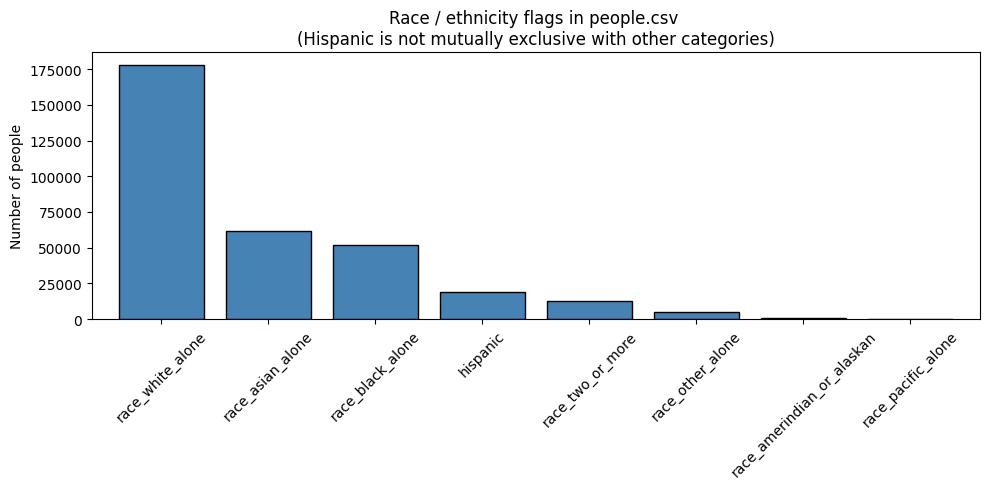

race_white_alone              177986
race_asian_alone               61492
race_black_alone               51582
hispanic                       18602
race_two_or_more               12942
race_other_alone                4644
race_amerindian_or_alaskan       809
race_pacific_alone               138
dtype: int64

In [6]:
people = pd.read_csv('pops/md_24027/pop_export/people.csv')

race_cols = [
    'race_white_alone',
    'race_black_alone',
    'race_amerindian_or_alaskan',
    'race_asian_alone',
    'race_pacific_alone',
    'race_other_alone',
    'race_two_or_more',
    'hispanic',
]

gp_counts = people[race_cols].fillna(0).astype(int).sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
gp_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black', width=0.8)
ax.set_ylabel('Number of people')
ax.set_xlabel('')
ax.set_title('Race / ethnicity flags in people.csv \n(Hispanic is not mutually exclusive with other categories)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

gp_counts

### Get counts of race/ethnicity categories from ACS data
Need to download tables B02001 (race categories) and B03003 (Hispanic or Latino)

In [7]:
# Download ACS tables with individual level race totals
from geopops.sources import get_census_metadata, get_census_data

# Use the same config / year as DownloadData
with open('pops/md_24027/config.json') as f:
    cfg = json.load(f)

year_ACS = cfg['main_year']          # e.g. 2019
api_key = cfg.get('census_api_key') or os.environ.get('CENSUS_API_KEY')
state_fips = '24'                    # MD
out_dir = 'pops/md_24027/census/MD'
os.makedirs(out_dir, exist_ok=True)

tables = ['B02001', 'B03003'] # B02001 is race categories, B03003 is Hispanic or Latino

ACS_metadata = get_census_metadata(name='acs/acs5', vintage=year_ACS)

for code in tables:
    data = get_census_data(
        name='acs/acs5',
        vintage=year_ACS,
        vars=[f'group({code})'],
        region='block group:*',
        regionin=f'state:{state_fips} county:*',
        key=api_key,
    )
    data = data.drop(columns=['state', 'county', 'tract', 'block group'], errors='ignore')

    cols = data.columns.to_list()
    if 'GEO_ID' in cols and 'NAME' in cols:
        cols = ['GEO_ID', 'NAME'] + [c for c in cols if c not in ('GEO_ID', 'NAME')]
        data = data[cols]

    data = data.astype(str)
    data_labels = ACS_metadata[ACS_metadata['name'].isin(data.columns)][['name', 'label']]
    label_dict = dict(zip(data_labels['name'], data_labels['label']))
    all_labels = {col: col for col in data.columns}
    all_labels.update(label_dict)
    label_df = pd.DataFrame([all_labels])

    data_with_labels = pd.concat([label_df, data], ignore_index=True)
    data_with_labels = data_with_labels.loc[:, ~data_with_labels.columns.str.endswith(('EA', 'M', 'MA'))]

    file_name = f'ACSDT5Y{year_ACS}.{code}-Data.csv'
    file_path = os.path.join(out_dir, file_name)
    data_with_labels.to_csv(file_path, index=False)
    print(f'-- {file_path}')

-- pops/md_24027/census/MD/ACSDT5Y2019.B02001-Data.csv
-- pops/md_24027/census/MD/ACSDT5Y2019.B03003-Data.csv


In [8]:
# Get ACS counts for race categories
B02001 = pd.read_csv('pops/md_24027/census/MD/ACSDT5Y2019.B02001-Data.csv')

# Drop the ACS label row (second spreadsheet row)
B02001 = B02001[B02001['GEO_ID'] != 'Geography'].copy()

# Howard County, MD (FIPS 24027)
howard = B02001[B02001['NAME'].str.contains('Howard County, Maryland', na=False)].copy()

race_map = {
    'B02001_002E': 'race_white_alone',
    'B02001_003E': 'race_black_alone',
    'B02001_004E': 'race_amerindian_or_alaskan',
    'B02001_005E': 'race_asian_alone',
    'B02001_006E': 'race_pacific_alone',
    'B02001_007E': 'race_other_alone',
    'B02001_008E': 'race_two_or_more',  # total two or more (not the 009/010 split)
}

for col in race_map:
    howard[col] = pd.to_numeric(howard[col], errors='coerce').fillna(0)

acs_counts = (
    howard[list(race_map.keys())]
    .sum()
    .rename(index=race_map)
    .astype(int)
    .rename('acs_count')
)

acs_counts

race_white_alone              181711
race_black_alone               60232
race_amerindian_or_alaskan       846
race_asian_alone               57613
race_pacific_alone                84
race_other_alone                4209
race_two_or_more               14160
Name: acs_count, dtype: int64

In [9]:
# Get ACS counts for Hispanic or Latino
B03003 = pd.read_csv('pops/md_24027/census/MD/ACSDT5Y2019.B03003-Data.csv')
B03003 = B03003[B03003['GEO_ID'] != 'Geography'].copy()

howard_hisp = B03003[B03003['NAME'].str.contains('Howard County, Maryland', na=False)].copy()
howard_hisp['B03003_003E'] = pd.to_numeric(howard_hisp['B03003_003E'], errors='coerce').fillna(0)

hispanic_count = int(howard_hisp['B03003_003E'].sum())  # Hispanic or Latino
acs_counts.loc['hispanic'] = hispanic_count

acs_counts

race_white_alone              181711
race_black_alone               60232
race_amerindian_or_alaskan       846
race_asian_alone               57613
race_pacific_alone                84
race_other_alone                4209
race_two_or_more               14160
hispanic                       22012
Name: acs_count, dtype: int64

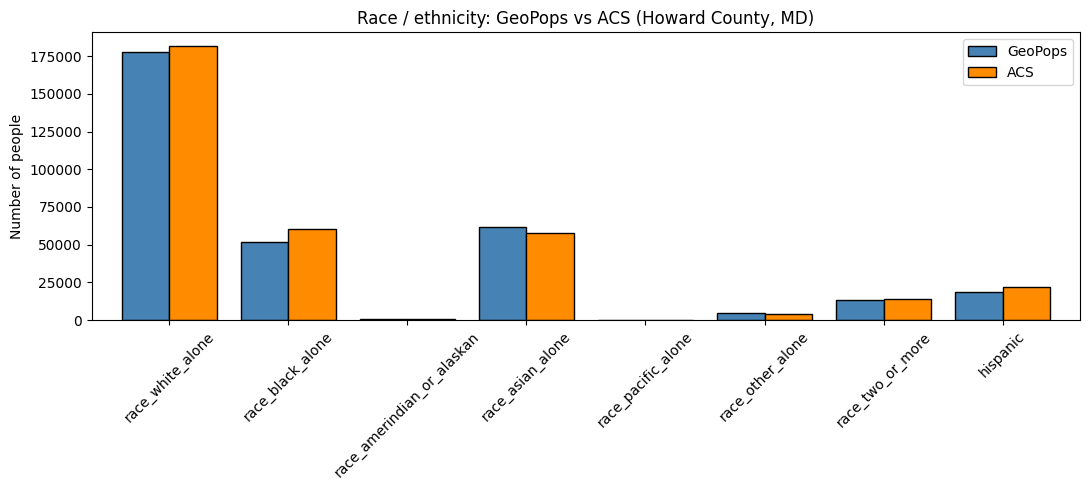

,GeoPops,ACS
race_white_alone,177986,181711
race_black_alone,51582,60232
race_amerindian_or_alaskan,809,846
race_asian_alone,61492,57613
race_pacific_alone,138,84
race_other_alone,4644,4209
race_two_or_more,12942,14160
hispanic,18602,22012


In [10]:
# Combine race and ethnicity variables for ACS data and plot against GeoPops data
race_cols = [
    'race_white_alone',
    'race_black_alone',
    'race_amerindian_or_alaskan',
    'race_asian_alone',
    'race_pacific_alone',
    'race_other_alone',
    'race_two_or_more',
    'hispanic',
]

compare = pd.DataFrame({
    'GeoPops': gp_counts.reindex(race_cols),
    'ACS': acs_counts.reindex(race_cols),
})

ax = compare.plot(
    kind='bar',
    figsize=(11, 5),
    width=0.8,
    edgecolor='black',
    color=['steelblue', 'darkorange'],
)
ax.set_ylabel('Number of people')
ax.set_xlabel('')
ax.set_title('Race / ethnicity: GeoPops vs ACS (Howard County, MD)')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='')
plt.tight_layout()
plt.show()

compare